In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append('..')
from src.components.cnn_model import Oblateness1DCNN

# 1. Load the Empirical Dataset
data_dir = "../data/synthetic"
X_train_flux = np.load(os.path.join(data_dir, "X_train.npy"))
y_train = np.load(os.path.join(data_dir, "y_train.npy"))
X_test_flux = np.load(os.path.join(data_dir, "X_test.npy"))
y_test = np.load(os.path.join(data_dir, "y_test.npy"))

# 2. Extract the Second Input (Transit Depth)
# Depth is simply 1.0 minus the lowest point of the U-shape
X_train_depth = 1.0 - np.min(X_train_flux, axis=1)
X_test_depth = 1.0 - np.min(X_test_flux, axis=1)

# 3. Convert all 3 arrays to PyTorch Tensors
X_train_flux_t = torch.tensor(X_train_flux, dtype=torch.float32)
X_train_depth_t = torch.tensor(X_train_depth, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_test_flux_t = torch.tensor(X_test_flux, dtype=torch.float32)
X_test_depth_t = torch.tensor(X_test_depth, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# 4. Create the Dual-Input DataLoaders
batch_size = 64
# Notice we are packing 3 things into the dataset now: Flux, Depth, and J2 Target
train_dataset = TensorDataset(X_train_flux_t, X_train_depth_t, y_train_t)
test_dataset = TensorDataset(X_test_flux_t, X_test_depth_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Dual-Input Data loaded! Training batches: {len(train_loader)}")

# 5. Initialize the Model
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

model = Oblateness1DCNN().to(device)
criterion = nn.MSELoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001)

Dual-Input Data loaded! Training batches: 63
Using device: mps


In [2]:
import time

# 1. Training Parameters
epochs = 75 # Increased slightly because real TESS noise is harder to learn
train_losses = []
test_losses = []

print(f"Starting Dual-Input Training on {device} for {epochs} epochs...")
start_time = time.time()

# 2. The Training Loop
for epoch in range(epochs):
    model.train() 
    running_train_loss = 0.0
    
    # We now unpack THREE items from the DataLoader
    for batch_flux, batch_depth, batch_y in train_loader:
        batch_flux = batch_flux.to(device)
        batch_depth = batch_depth.to(device)
        batch_y = batch_y.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass: Feed BOTH inputs into the model
        predictions = model(batch_flux, batch_depth)
        
        loss = criterion(predictions, batch_y)
        
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * batch_flux.size(0)
        
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)
    
    # 3. Validation Phase
    model.eval() 
    running_test_loss = 0.0
    
    with torch.no_grad(): 
        for batch_flux, batch_depth, batch_y in test_loader:
            batch_flux = batch_flux.to(device)
            batch_depth = batch_depth.to(device)
            batch_y = batch_y.to(device)
            
            predictions = model(batch_flux, batch_depth)
            loss = criterion(predictions, batch_y)
            
            running_test_loss += loss.item() * batch_flux.size(0)
            
    epoch_test_loss = running_test_loss / len(test_loader.dataset)
    test_losses.append(epoch_test_loss)
    
    # Print progress every 5 epochs
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_train_loss:.6f} | Test Loss: {epoch_test_loss:.6f}")

end_time = time.time()
print(f"Training completed in {(end_time - start_time)/60:.2f} minutes.")

Starting Dual-Input Training on mps for 75 epochs...
Epoch [5/75] | Train Loss: 0.000220 | Test Loss: 0.000206
Epoch [10/75] | Train Loss: 0.000215 | Test Loss: 0.000235
Epoch [15/75] | Train Loss: 0.000211 | Test Loss: 0.000205
Epoch [20/75] | Train Loss: 0.000210 | Test Loss: 0.000206
Epoch [25/75] | Train Loss: 0.000211 | Test Loss: 0.000204
Epoch [30/75] | Train Loss: 0.000211 | Test Loss: 0.000204
Epoch [35/75] | Train Loss: 0.000210 | Test Loss: 0.000204
Epoch [40/75] | Train Loss: 0.000211 | Test Loss: 0.000204
Epoch [45/75] | Train Loss: 0.000213 | Test Loss: 0.000206
Epoch [50/75] | Train Loss: 0.000212 | Test Loss: 0.000207
Epoch [55/75] | Train Loss: 0.000211 | Test Loss: 0.000204
Epoch [60/75] | Train Loss: 0.000212 | Test Loss: 0.000204
Epoch [65/75] | Train Loss: 0.000211 | Test Loss: 0.000208
Epoch [70/75] | Train Loss: 0.000213 | Test Loss: 0.000205
Epoch [75/75] | Train Loss: 0.000210 | Test Loss: 0.000204
Training completed in 0.93 minutes.


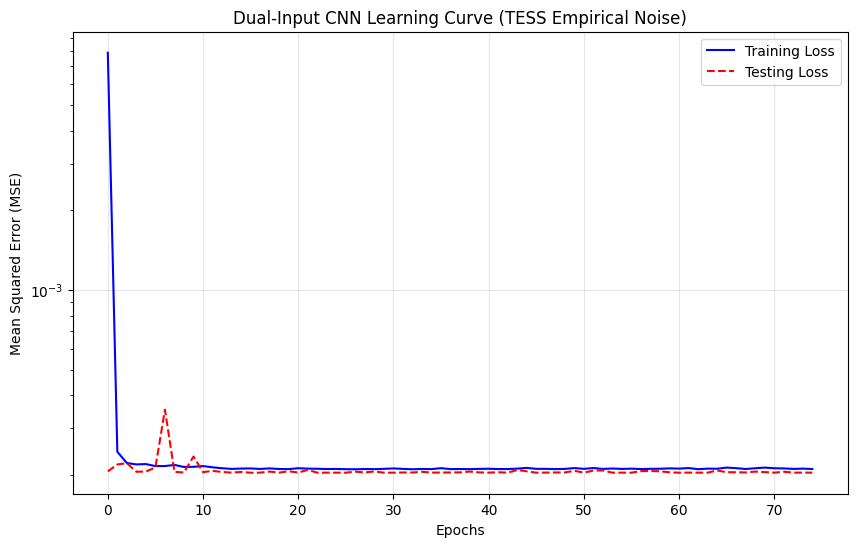

Empirical Model weights saved to ../models/weights/j2_empirical_cnn.pt


In [3]:
# 1. Plot the Learning Curve
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', color='blue')
plt.plot(test_losses, label='Testing Loss', color='red', linestyle='--')
plt.title('Dual-Input CNN Learning Curve (TESS Empirical Noise)')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. Save the trained model weights
save_path = "../models/weights/j2_empirical_cnn.pt"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
torch.save(model.state_dict(), save_path)
print(f"Empirical Model weights saved to {save_path}")